## Cell 1 — Imports and configuration

In [1]:
from __future__ import annotations

import gc
import json
import shutil
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from matplotlib import cm
from matplotlib.patches import Rectangle


print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

if not tf.config.list_physical_devices("GPU"):
    raise RuntimeError(
        "GPU was not detected. Enable a Kaggle GPU accelerator."
    )

RANDOM_SEED = 42
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
NUMBER_OF_CLASSES = 43
BATCH_SIZE = 32

HIGH_CONFIDENCE_SAMPLES = 4
LOW_CONFIDENCE_SAMPLES = 4
DIFFICULT_SAMPLES = 4

# Keep only the ZIP archive in /kaggle/working after completion.
REMOVE_UNPACKED_OUTPUT_AFTER_ZIP = True

tf.keras.utils.set_random_seed(RANDOM_SEED)


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Locate GTSRB and the three models

In [2]:
INPUT_ROOT = Path("/kaggle/input")


def find_gtsrb_root() -> Path:
    # Locate GTSRB by checking its CSV files and image folders.
    for train_csv in INPUT_ROOT.rglob("Train.csv"):
        candidate = train_csv.parent

        if (
            (candidate / "Test.csv").exists()
            and (candidate / "Train").is_dir()
            and (candidate / "Test").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "The GTSRB dataset root was not found."
    )


def find_model_file(filename: str) -> Path:
    # Search recursively because Kaggle may add directory levels.
    matches = sorted(
        INPUT_ROOT.rglob(filename),
        key=lambda path: (
            len(path.parts),
            str(path),
        ),
    )

    if not matches:
        raise FileNotFoundError(
            f"The model file was not found: {filename}"
        )

    if len(matches) > 1:
        print(f"Warning: multiple matches found for {filename}")

        for match in matches:
            print(" ", match)

        print("Using:", matches[0])

    return matches[0]


DATASET_ROOT = find_gtsrb_root()

MODEL_PATHS = {
    "Custom CNN": find_model_file(
        "best_custom_cnn.keras"
    ),
    "EfficientNetV2B0": find_model_file(
        "best_efficientnetv2b0.keras"
    ),
    "ConvNeXtTiny": find_model_file(
        "best_convnexttiny.keras"
    ),
}

MODEL_INPUT_RANGES = {
    "Custom CNN": "zero_one",
    "EfficientNetV2B0": "zero_255",
    "ConvNeXtTiny": "zero_255",
}

print("GTSRB root:", DATASET_ROOT)

for model_name, model_path in MODEL_PATHS.items():
    print(f"{model_name}: {model_path}")


GTSRB root: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
Custom CNN: /kaggle/input/datasets/yuriyrizoboyev/traffic-sign-best-models/best_custom_cnn.keras
EfficientNetV2B0: /kaggle/input/datasets/yuriyrizoboyev/traffic-sign-best-models/best_efficientnetv2b0.keras
ConvNeXtTiny: /kaggle/input/datasets/yuriyrizoboyev/traffic-sign-best-models/best_convnexttiny.keras


## Cell 3 — Output folders and class names

In [3]:
OUTPUT_ROOT = Path(
    "/kaggle/working/gradcam_outputs"
)

REPORT_DIR = OUTPUT_ROOT / "reports"
FIGURE_DIR = OUTPUT_ROOT / "figures"
COMPARISON_DIR = FIGURE_DIR / "comparisons"
INDIVIDUAL_DIR = FIGURE_DIR / "individual"
HEATMAP_ARRAY_DIR = OUTPUT_ROOT / "heatmap_arrays"

for directory in [
    REPORT_DIR,
    COMPARISON_DIR,
    INDIVIDUAL_DIR,
    HEATMAP_ARRAY_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


CLASS_NAMES = {
    0: "Speed limit 20 km/h",
    1: "Speed limit 30 km/h",
    2: "Speed limit 50 km/h",
    3: "Speed limit 60 km/h",
    4: "Speed limit 70 km/h",
    5: "Speed limit 80 km/h",
    6: "End of speed limit 80 km/h",
    7: "Speed limit 100 km/h",
    8: "Speed limit 120 km/h",
    9: "No passing",
    10: "No passing for vehicles over 3.5 t",
    11: "Right-of-way at the next intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles over 3.5 t prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve to the left",
    20: "Dangerous curve to the right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on the right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice or snow",
    31: "Wild animals crossing",
    32: "End of speed and passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing for vehicles over 3.5 t",
}

if len(CLASS_NAMES) != NUMBER_OF_CLASSES:
    raise ValueError("The class-name mapping must contain 43 classes.")

print("Output root:", OUTPUT_ROOT)


Output root: /kaggle/working/gradcam_outputs


## Cell 4 — Load and validate the official test set

In [4]:
test_frame = pd.read_csv(
    DATASET_ROOT / "Test.csv"
)

required_columns = [
    "Path",
    "ClassId",
]

missing_columns = [
    column
    for column in required_columns
    if column not in test_frame.columns
]

if missing_columns:
    raise KeyError(
        f"Missing Test.csv columns: {missing_columns}"
    )


def resolve_image_path(relative_path: str) -> str:
    # Normalize path separators and create an absolute path.
    normalized = (
        str(relative_path)
        .replace("\\", "/")
        .lstrip("/")
    )

    return str(
        DATASET_ROOT / normalized
    )


test_frame["absolute_path"] = (
    test_frame["Path"]
    .map(resolve_image_path)
)

missing_images = [
    path
    for path in test_frame["absolute_path"]
    if not Path(path).exists()
]

if missing_images:
    raise FileNotFoundError(
        f"{len(missing_images)} test images were not found. "
        f"First missing image: {missing_images[0]}"
    )

if len(test_frame) != 12630:
    raise ValueError(
        f"Expected 12630 test images, found {len(test_frame)}."
    )

TEST_PATHS = test_frame["absolute_path"].astype(str).to_numpy()
TRUE_LABELS = test_frame["ClassId"].astype(np.int64).to_numpy()

ROI_COLUMNS = [
    "Width",
    "Height",
    "Roi.X1",
    "Roi.Y1",
    "Roi.X2",
    "Roi.Y2",
]

ROI_AVAILABLE = all(
    column in test_frame.columns
    for column in ROI_COLUMNS
)

print("Test images:", len(test_frame))
print("Classes:", test_frame["ClassId"].nunique())
print("ROI columns available:", ROI_AVAILABLE)

display(
    test_frame[
        ["Path", "ClassId"]
    ].head()
)


Test images: 12630
Classes: 43
ROI columns available: True


,Path,ClassId
0,Test/00000.png,16
1,Test/00001.png,1
2,Test/00002.png,38
3,Test/00003.png,33
4,Test/00004.png,11


## Cell 5 — Image loading and preprocessing

In [5]:
def load_image_255(
    path: tf.Tensor,
) -> tf.Tensor:
    # Load and resize an RGB image in the [0, 255] range.
    image_bytes = tf.io.read_file(path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )

    image.set_shape(
        [None, None, 3]
    )

    image = tf.image.resize(
        image,
        [IMAGE_HEIGHT, IMAGE_WIDTH],
        method="bilinear",
        antialias=True,
    )

    image = tf.cast(
        image,
        tf.float32,
    )

    image = tf.clip_by_value(
        image,
        0.0,
        255.0,
    )

    return tf.ensure_shape(
        image,
        [IMAGE_HEIGHT, IMAGE_WIDTH, 3],
    )


def prepare_model_input(
    image_255: tf.Tensor,
    input_range: str,
) -> tf.Tensor:
    # Match the input range used during model training.
    if input_range == "zero_one":
        return image_255 / 255.0

    if input_range == "zero_255":
        return image_255

    raise ValueError(
        f"Unsupported input range: {input_range}"
    )


def build_prediction_dataset(
    input_range: str,
) -> tf.data.Dataset:
    # Preserve the exact Test.csv order.
    dataset = tf.data.Dataset.from_tensor_slices(
        TEST_PATHS
    )

    options = tf.data.Options()
    options.experimental_deterministic = True
    dataset = dataset.with_options(options)

    def map_example(
        image_path: tf.Tensor,
    ) -> tf.Tensor:
        image_255 = load_image_255(
            image_path
        )

        return prepare_model_input(
            image_255,
            input_range,
        )

    dataset = dataset.map(
        map_example,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True,
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False,
    )

    return dataset.prefetch(
        tf.data.AUTOTUNE
    )


## Cell 6 — Validate models and predict the clean test set

In [6]:
prediction_store: dict[
    str,
    np.ndarray,
] = {}

analysis_frame = test_frame.copy()
model_information = []


for model_name, model_path in MODEL_PATHS.items():
    print()
    print("=" * 80)
    print("Processing:", model_name)
    print("=" * 80)

    tf.keras.backend.clear_session()
    gc.collect()

    model = tf.keras.models.load_model(
        model_path,
        compile=False,
    )

    if tuple(model.input_shape[1:]) != (
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        3,
    ):
        raise ValueError(
            f"{model_name} has an invalid input shape: "
            f"{model.input_shape}"
        )

    if int(model.output_shape[-1]) != NUMBER_OF_CLASSES:
        raise ValueError(
            f"{model_name} has an invalid output shape: "
            f"{model.output_shape}"
        )

    model_information.append(
        {
            "model": model_name,
            "input_shape": str(model.input_shape),
            "output_shape": str(model.output_shape),
            "parameter_count": int(model.count_params()),
            "model_file_size_mb": float(
                model_path.stat().st_size
                / 1024
                / 1024
            ),
        }
    )

    dataset = build_prediction_dataset(
        MODEL_INPUT_RANGES[
            model_name
        ]
    )

    probabilities = model.predict(
        dataset,
        verbose=0,
    )

    expected_shape = (
        len(test_frame),
        NUMBER_OF_CLASSES,
    )

    if probabilities.shape != expected_shape:
        raise ValueError(
            f"{model_name} returned {probabilities.shape}; "
            f"expected {expected_shape}."
        )

    prediction_store[
        model_name
    ] = probabilities.astype(
        np.float32
    )

    predicted_classes = np.argmax(
        probabilities,
        axis=1,
    )

    confidences = np.max(
        probabilities,
        axis=1,
    )

    model_key = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    analysis_frame[
        f"{model_key}_predicted_class"
    ] = predicted_classes

    analysis_frame[
        f"{model_key}_confidence"
    ] = confidences

    analysis_frame[
        f"{model_key}_correct"
    ] = (
        predicted_classes
        == TRUE_LABELS
    )

    print(
        "Clean accuracy:",
        float(
            np.mean(
                predicted_classes
                == TRUE_LABELS
            )
        ),
    )

    del model
    del dataset
    gc.collect()


pd.DataFrame(
    model_information
).to_csv(
    REPORT_DIR / "model_information.csv",
    index=False,
)

analysis_frame.to_csv(
    REPORT_DIR / "clean_test_predictions_all_models.csv",
    index=False,
)

tf.keras.backend.clear_session()
gc.collect()

print("Clean predictions completed.")



Processing: Custom CNN


I0000 00:00:1784774554.679106      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1784774560.988779      66 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Clean accuracy: 0.8536817102137767

Processing: EfficientNetV2B0
Clean accuracy: 0.847347585114806

Processing: ConvNeXtTiny
Clean accuracy: 0.934916864608076
Clean predictions completed.


## Cell 7 — Select 12 representative samples

In [7]:
model_keys = [
    model_name
    .lower()
    .replace(" ", "_")
    for model_name in MODEL_PATHS
]

correct_columns = [
    f"{model_key}_correct"
    for model_key in model_keys
]

confidence_columns = [
    f"{model_key}_confidence"
    for model_key in model_keys
]

analysis_frame[
    "all_models_correct"
] = analysis_frame[
    correct_columns
].all(
    axis=1
)

analysis_frame[
    "wrong_model_count"
] = (
    len(correct_columns)
    - analysis_frame[
        correct_columns
    ].sum(
        axis=1
    )
)

analysis_frame[
    "mean_confidence"
] = analysis_frame[
    confidence_columns
].mean(
    axis=1
)

analysis_frame[
    "minimum_confidence"
] = analysis_frame[
    confidence_columns
].min(
    axis=1
)


def select_unique_rows(
    candidates: pd.DataFrame,
    count: int,
    category: str,
    used_indices: set[int],
) -> pd.DataFrame:
    # Select rows that have not already been used.
    available = candidates[
        ~candidates.index.isin(
            used_indices
        )
    ].head(count).copy()

    available[
        "selection_category"
    ] = category

    used_indices.update(
        int(index)
        for index in available.index
    )

    return available


used_indices: set[int] = set()
selected_parts = []


high_candidates = (
    analysis_frame[
        analysis_frame[
            "all_models_correct"
        ]
    ]
    .sort_values(
        [
            "mean_confidence",
            "minimum_confidence",
        ],
        ascending=[
            False,
            False,
        ],
    )
)

selected_parts.append(
    select_unique_rows(
        high_candidates,
        HIGH_CONFIDENCE_SAMPLES,
        "high_confidence_correct",
        used_indices,
    )
)


low_candidates = (
    analysis_frame[
        analysis_frame[
            "all_models_correct"
        ]
    ]
    .sort_values(
        [
            "mean_confidence",
            "minimum_confidence",
        ],
        ascending=[
            True,
            True,
        ],
    )
)

selected_parts.append(
    select_unique_rows(
        low_candidates,
        LOW_CONFIDENCE_SAMPLES,
        "low_confidence_correct",
        used_indices,
    )
)


difficult_candidates = (
    analysis_frame[
        analysis_frame[
            "wrong_model_count"
        ] > 0
    ]
    .sort_values(
        [
            "wrong_model_count",
            "mean_confidence",
        ],
        ascending=[
            False,
            False,
        ],
    )
)

selected_parts.append(
    select_unique_rows(
        difficult_candidates,
        DIFFICULT_SAMPLES,
        "difficult_or_misclassified",
        used_indices,
    )
)


selected_frame = pd.concat(
    selected_parts,
    axis=0,
)

expected_count = (
    HIGH_CONFIDENCE_SAMPLES
    + LOW_CONFIDENCE_SAMPLES
    + DIFFICULT_SAMPLES
)

if len(selected_frame) < expected_count:
    fallback_count = (
        expected_count
        - len(selected_frame)
    )

    fallback_candidates = (
        analysis_frame[
            ~analysis_frame.index.isin(
                used_indices
            )
        ]
        .sort_values(
            "mean_confidence",
            ascending=True,
        )
    )

    selected_frame = pd.concat(
        [
            selected_frame,
            select_unique_rows(
                fallback_candidates,
                fallback_count,
                "fallback_difficult",
                used_indices,
            ),
        ],
        axis=0,
    )


selected_frame = (
    selected_frame
    .reset_index()
    .rename(
        columns={
            "index": "test_row_index"
        }
    )
)

selected_frame.insert(
    0,
    "sample_id",
    [
        f"sample_{index:02d}"
        for index in range(
            1,
            len(selected_frame) + 1
        )
    ],
)

selected_frame[
    "true_class_name"
] = selected_frame[
    "ClassId"
].map(
    CLASS_NAMES
)

selected_frame.to_csv(
    REPORT_DIR / "selected_gradcam_samples.csv",
    index=False,
)

display(
    selected_frame[
        [
            "sample_id",
            "selection_category",
            "ClassId",
            "true_class_name",
            "wrong_model_count",
            "mean_confidence",
            "Path",
        ]
    ]
)


,sample_id,selection_category,ClassId,true_class_name,wrong_model_count,mean_confidence,Path
0,sample_01,high_confidence_correct,13,Yield,0,1.000000,Test/00026.png
1,sample_02,high_confidence_correct,17,No entry,0,1.000000,Test/00031.png
2,sample_03,high_confidence_correct,12,Priority road,0,1.000000,Test/00037.png
3,sample_04,high_confidence_correct,13,Yield,0,1.000000,Test/00054.png
4,sample_05,low_confidence_correct,2,Speed limit 50 km/h,0,0.505970,Test/07491.png
5,sample_06,low_confidence_correct,3,Speed limit 60 km/h,0,0.538991,Test/07837.png
6,sample_07,low_confidence_correct,2,Speed limit 50 km/h,0,0.539963,Test/03773.png
7,sample_08,low_confidence_correct,2,Speed limit 50 km/h,0,0.556238,Test/04476.png
8,sample_09,difficult_or_misclassified,37,Go straight or left,3,0.994686,Test/03789.png
9,sample_10,difficult_or_misclassified,5,Speed limit 80 km/h,3,0.985951,Test/04422.png


## Cell 8 — Grad-CAM and ROI utility functions

In [8]:
def output_rank(
    layer: tf.keras.layers.Layer,
) -> int | None:
    # Return the rank of a layer output when it is available.
    try:
        return len(
            layer.output.shape
        )

    except Exception:
        return None


def call_layer_for_inference(
    layer: tf.keras.layers.Layer,
    inputs: tf.Tensor,
) -> tf.Tensor:
    # Call a layer in inference mode when the layer supports training.
    try:
        return layer(
            inputs,
            training=False,
        )

    except TypeError:
        return layer(
            inputs
        )


def direct_spatial_layers(
    model: tf.keras.Model,
) -> list[tf.keras.layers.Layer]:
    # Find non-nested top-level layers with spatial feature outputs.
    candidates = []

    for layer in reversed(
        model.layers
    ):
        if isinstance(
            layer,
            tf.keras.layers.InputLayer,
        ):
            continue

        # Nested models require a separate Grad-CAM construction.
        if isinstance(
            layer,
            tf.keras.Model,
        ):
            continue

        if output_rank(layer) == 4:
            candidates.append(
                layer
            )

    return candidates


def nested_spatial_layers(
    nested_model: tf.keras.Model,
) -> list[tf.keras.layers.Layer]:
    # Find spatial layers inside a nested backbone.
    candidates = []

    for layer in reversed(
        nested_model.layers
    ):
        if isinstance(
            layer,
            tf.keras.layers.InputLayer,
        ):
            continue

        if output_rank(layer) == 4:
            candidates.append(
                layer
            )

    return candidates


def make_logits_output(
    model: tf.keras.Model,
) -> None:
    # Replace the final softmax activation with a linear activation.
    final_layer = model.layers[-1]

    if not hasattr(
        final_layer,
        "activation",
    ):
        return

    activation_name = (
        tf.keras.activations.serialize(
            final_layer.activation
        )
    )

    if activation_name == "softmax":
        final_layer.activation = (
            tf.keras.activations.linear
        )


def validate_grad_model(
    grad_model: tf.keras.Model,
    sample_input: tf.Tensor,
    sample_class_index: int,
) -> tuple[
    bool,
    str | None,
]:
    # Check that feature maps are connected to the selected class output.
    try:
        with tf.GradientTape() as tape:
            feature_maps, logits = grad_model(
                sample_input,
                training=False,
            )

            class_score = logits[
                :,
                sample_class_index
            ]

        gradients = tape.gradient(
            class_score,
            feature_maps,
        )

        if gradients is None:
            return (
                False,
                "gradients were None",
            )

        if feature_maps.shape.rank != 4:
            return (
                False,
                "feature-map rank was not 4",
            )

        if not bool(
            tf.reduce_all(
                tf.math.is_finite(
                    gradients
                )
            ).numpy()
        ):
            return (
                False,
                "gradients contained non-finite values",
            )

        return (
            True,
            None,
        )

    except Exception as error:
        return (
            False,
            f"{type(error).__name__}: {error}",
        )


def build_nested_grad_model(
    outer_model: tf.keras.Model,
    nested_model_index: int,
    target_layer: tf.keras.layers.Layer,
) -> tf.keras.Model:
    # Rebuild the forward path so the internal feature map remains connected
    # to the classifier output of the outer model.
    nested_model = outer_model.layers[
        nested_model_index
    ]

    if not isinstance(
        nested_model,
        tf.keras.Model,
    ):
        raise TypeError(
            "The selected outer layer is not a nested Keras model."
        )

    # Return both the selected internal feature map and backbone output
    # from one shared execution of the nested backbone.
    nested_feature_model = tf.keras.Model(
        inputs=nested_model.inputs,
        outputs=[
            target_layer.output,
            nested_model.output,
        ],
        name=(
            f"{nested_model.name}_"
            f"{target_layer.name}_gradcam"
        ),
    )

    outer_input = outer_model.input
    x = outer_input

    # Apply any top-level layers that appear before the nested backbone.
    for layer in outer_model.layers[
        1:nested_model_index
    ]:
        x = call_layer_for_inference(
            layer,
            x,
        )

    feature_maps, x = nested_feature_model(
        x,
        training=False,
    )

    # Apply the classifier layers that follow the nested backbone.
    for layer in outer_model.layers[
        nested_model_index + 1:
    ]:
        x = call_layer_for_inference(
            layer,
            x,
        )

    return tf.keras.Model(
        inputs=outer_input,
        outputs=[
            feature_maps,
            x,
        ],
        name=(
            f"{outer_model.name}_"
            f"{target_layer.name}_gradcam"
        ),
    )


def find_working_gradcam_layer(
    model: tf.keras.Model,
    sample_input: tf.Tensor,
    sample_class_index: int,
) -> tuple[
    tf.keras.layers.Layer,
    tf.keras.Model,
]:
    # First test ordinary spatial layers of a non-nested architecture.
    errors = []

    for layer in direct_spatial_layers(
        model
    ):
        try:
            grad_model = tf.keras.Model(
                inputs=model.inputs,
                outputs=[
                    layer.output,
                    model.output,
                ],
            )

            is_valid, error_message = (
                validate_grad_model(
                    grad_model,
                    sample_input,
                    sample_class_index,
                )
            )

            if is_valid:
                print(
                    "Selected direct layer:",
                    layer.name,
                    "| shape:",
                    grad_model.outputs[0].shape,
                )

                return (
                    layer,
                    grad_model,
                )

            errors.append(
                f"Direct {layer.name}: "
                f"{error_message}"
            )

        except Exception as error:
            errors.append(
                f"Direct {layer.name}: "
                f"{type(error).__name__}: {error}"
            )

    # Then inspect nested application backbones such as EfficientNetV2
    # and ConvNeXtTiny.
    for nested_model_index in reversed(
        range(
            len(model.layers)
        )
    ):
        nested_model = model.layers[
            nested_model_index
        ]

        if not isinstance(
            nested_model,
            tf.keras.Model,
        ):
            continue

        print(
            "Inspecting nested backbone:",
            nested_model.name,
        )

        for target_layer in nested_spatial_layers(
            nested_model
        ):
            try:
                grad_model = (
                    build_nested_grad_model(
                        model,
                        nested_model_index,
                        target_layer,
                    )
                )

                is_valid, error_message = (
                    validate_grad_model(
                        grad_model,
                        sample_input,
                        sample_class_index,
                    )
                )

                if is_valid:
                    print(
                        "Selected nested layer:",
                        (
                            f"{nested_model.name}/"
                            f"{target_layer.name}"
                        ),
                        "| shape:",
                        grad_model.outputs[0].shape,
                    )

                    return (
                        target_layer,
                        grad_model,
                    )

                errors.append(
                    f"Nested "
                    f"{nested_model.name}/"
                    f"{target_layer.name}: "
                    f"{error_message}"
                )

            except Exception as error:
                errors.append(
                    f"Nested "
                    f"{nested_model.name}/"
                    f"{target_layer.name}: "
                    f"{type(error).__name__}: "
                    f"{error}"
                )

    error_preview = "\n".join(
        errors[-20:]
    )

    raise RuntimeError(
        "No spatial layer produced valid Grad-CAM gradients.\n"
        "Last tested layers:\n"
        f"{error_preview}"
    )


def create_gradcam_heatmap(
    grad_model: tf.keras.Model,
    model_input: tf.Tensor,
    class_index: int,
) -> np.ndarray:
    # Compute a normalized Grad-CAM heatmap for one target class.
    with tf.GradientTape() as tape:
        feature_maps, logits = grad_model(
            model_input,
            training=False,
        )

        class_score = logits[
            :,
            class_index
        ]

    gradients = tape.gradient(
        class_score,
        feature_maps,
    )

    if gradients is None:
        raise RuntimeError(
            "Gradients were not available for the selected layer."
        )

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(
            0,
            1,
            2,
        ),
    )

    feature_maps = feature_maps[0]

    heatmap = tf.reduce_sum(
        feature_maps
        * pooled_gradients,
        axis=-1,
    )

    heatmap = tf.nn.relu(
        heatmap
    )

    maximum = tf.reduce_max(
        heatmap
    )

    heatmap = tf.where(
        maximum > 0,
        heatmap / maximum,
        heatmap,
    )

    return heatmap.numpy().astype(
        np.float32
    )


def resize_heatmap(
    heatmap: np.ndarray,
) -> np.ndarray:
    # Resize the Grad-CAM heatmap to the model input resolution.
    resized = tf.image.resize(
        heatmap[
            ...,
            np.newaxis,
        ],
        [
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
        ],
        method="bilinear",
    )[
        ...,
        0
    ]

    resized = tf.clip_by_value(
        resized,
        0.0,
        1.0,
    )

    return resized.numpy().astype(
        np.float32
    )


def create_overlay(
    image_255: np.ndarray,
    heatmap_224: np.ndarray,
    alpha: float = 0.40,
) -> np.ndarray:
    # Apply a color map and blend it with the original image.
    color_map = plt.get_cmap(
        "jet"
    )

    colored_heatmap = color_map(
        heatmap_224
    )[
        ...,
        :3
    ]

    colored_heatmap = (
        colored_heatmap
        * 255.0
    )

    overlay = (
        image_255.astype(
            np.float32
        )
        * (1.0 - alpha)
        + colored_heatmap.astype(
            np.float32
        )
        * alpha
    )

    return np.clip(
        overlay,
        0.0,
        255.0,
    ).astype(
        np.uint8
    )


def resized_roi(
    row: pd.Series,
) -> tuple[
    int,
    int,
    int,
    int,
] | None:
    # Convert the original ROI coordinates to 224 x 224 coordinates.
    if not ROI_AVAILABLE:
        return None

    original_width = float(
        row["Width"]
    )

    original_height = float(
        row["Height"]
    )

    if (
        original_width <= 0
        or original_height <= 0
    ):
        return None

    x_scale = (
        IMAGE_WIDTH
        / original_width
    )

    y_scale = (
        IMAGE_HEIGHT
        / original_height
    )

    x1 = int(
        round(
            float(
                row["Roi.X1"]
            )
            * x_scale
        )
    )

    y1 = int(
        round(
            float(
                row["Roi.Y1"]
            )
            * y_scale
        )
    )

    x2 = int(
        round(
            float(
                row["Roi.X2"]
            )
            * x_scale
        )
    )

    y2 = int(
        round(
            float(
                row["Roi.Y2"]
            )
            * y_scale
        )
    )

    x1 = int(
        np.clip(
            x1,
            0,
            IMAGE_WIDTH - 1,
        )
    )

    y1 = int(
        np.clip(
            y1,
            0,
            IMAGE_HEIGHT - 1,
        )
    )

    x2 = int(
        np.clip(
            x2,
            x1 + 1,
            IMAGE_WIDTH,
        )
    )

    y2 = int(
        np.clip(
            y2,
            y1 + 1,
            IMAGE_HEIGHT,
        )
    )

    return (
        x1,
        y1,
        x2,
        y2,
    )


def roi_attention_ratio(
    heatmap_224: np.ndarray,
    roi: tuple[
        int,
        int,
        int,
        int,
    ] | None,
) -> float | None:
    # Calculate the fraction of Grad-CAM energy inside the sign ROI.
    if roi is None:
        return None

    total_energy = float(
        heatmap_224.sum()
    )

    if total_energy <= 0:
        return 0.0

    x1, y1, x2, y2 = roi

    roi_energy = float(
        heatmap_224[
            y1:y2,
            x1:x2,
        ].sum()
    )

    return (
        roi_energy
        / total_energy
    )


def safe_model_name(
    model_name: str,
) -> str:
    # Convert a model display name into a safe directory name.
    return (
        model_name
        .lower()
        .replace(
            " ",
            "_",
        )
    )

## Cell 9 — Detect Grad-CAM target layers

In [9]:
target_layer_records = []

sample_row = selected_frame.iloc[0]
sample_image_255 = load_image_255(
    tf.constant(
        sample_row[
            "absolute_path"
        ]
    )
)


for model_name, model_path in MODEL_PATHS.items():
    print()
    print("=" * 80)
    print("Detecting layer for:", model_name)
    print("=" * 80)

    tf.keras.backend.clear_session()
    gc.collect()

    model = tf.keras.models.load_model(
        model_path,
        compile=False,
    )

    make_logits_output(
        model
    )

    model_input = prepare_model_input(
        sample_image_255,
        MODEL_INPUT_RANGES[
            model_name
        ],
    )[
        tf.newaxis,
        ...
    ]

    test_row_index = int(
        sample_row[
            "test_row_index"
        ]
    )

    predicted_class = int(
        np.argmax(
            prediction_store[
                model_name
            ][
                test_row_index
            ]
        )
    )

    target_layer, grad_model = (
        find_working_gradcam_layer(
            model,
            model_input,
            predicted_class,
        )
    )

    target_layer_records.append(
        {
            "model": model_name,
            "target_layer": target_layer.name,
            "target_output_shape": str(
                target_layer.output.shape
            ),
        }
    )

    del grad_model
    del model
    gc.collect()


target_layer_frame = pd.DataFrame(
    target_layer_records
)

target_layer_frame.to_csv(
    REPORT_DIR / "gradcam_target_layers.csv",
    index=False,
)

display(
    target_layer_frame
)



Detecting layer for: Custom CNN
Selected direct layer: block4_pool | shape: (None, 14, 14, 256)

Detecting layer for: EfficientNetV2B0
Inspecting nested backbone: efficientnetv2-b0
Selected nested layer: efficientnetv2-b0/top_activation | shape: (None, 7, 7, 1280)

Detecting layer for: ConvNeXtTiny
Inspecting nested backbone: convnext_tiny
Selected nested layer: convnext_tiny/layer_normalization | shape: (None, 7, 7, 768)


,model,target_layer,target_output_shape
0,Custom CNN,block4_pool,"(None, 14, 14, 256)"
1,EfficientNetV2B0,top_activation,"(None, 7, 7, 1280)"
2,ConvNeXtTiny,layer_normalization,"(None, 7, 7, 768)"


## Cell 10 — Generate individual Grad-CAM explanations

In [10]:
gradcam_records: list[
    dict[str, Any]
] = []

comparison_data: dict[
    str,
    dict[str, Any]
] = {}


for _, row in selected_frame.iterrows():
    sample_id = str(
        row["sample_id"]
    )

    image_255 = load_image_255(
        tf.constant(
            row["absolute_path"]
        )
    ).numpy().astype(
        np.uint8
    )

    comparison_data[
        sample_id
    ] = {
        "row": row,
        "image": image_255,
        "roi": resized_roi(row),
        "overlays": {},
        "predictions": {},
    }


for model_name, model_path in MODEL_PATHS.items():
    print()
    print("=" * 80)
    print("Generating Grad-CAM for:", model_name)
    print("=" * 80)

    tf.keras.backend.clear_session()
    gc.collect()

    model = tf.keras.models.load_model(
        model_path,
        compile=False,
    )

    make_logits_output(
        model
    )

    first_row = selected_frame.iloc[0]

    first_image = load_image_255(
        tf.constant(
            first_row[
                "absolute_path"
            ]
        )
    )

    first_input = prepare_model_input(
        first_image,
        MODEL_INPUT_RANGES[
            model_name
        ],
    )[
        tf.newaxis,
        ...
    ]

    first_index = int(
        first_row[
            "test_row_index"
        ]
    )

    first_class = int(
        np.argmax(
            prediction_store[
                model_name
            ][
                first_index
            ]
        )
    )

    target_layer, grad_model = (
        find_working_gradcam_layer(
            model,
            first_input,
            first_class,
        )
    )

    model_key = safe_model_name(
        model_name
    )

    model_figure_dir = (
        INDIVIDUAL_DIR
        / model_key
    )

    model_array_dir = (
        HEATMAP_ARRAY_DIR
        / model_key
    )

    model_figure_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    model_array_dir.mkdir(
        parents=True,
        exist_ok=True,
    )


    for _, row in selected_frame.iterrows():
        sample_id = str(
            row[
                "sample_id"
            ]
        )

        test_row_index = int(
            row[
                "test_row_index"
            ]
        )

        true_class = int(
            row[
                "ClassId"
            ]
        )

        probabilities = prediction_store[
            model_name
        ][
            test_row_index
        ]

        predicted_class = int(
            np.argmax(
                probabilities
            )
        )

        confidence = float(
            probabilities[
                predicted_class
            ]
        )

        image_tensor = load_image_255(
            tf.constant(
                row[
                    "absolute_path"
                ]
            )
        )

        image_255 = image_tensor.numpy().astype(
            np.uint8
        )

        model_input = prepare_model_input(
            image_tensor,
            MODEL_INPUT_RANGES[
                model_name
            ],
        )[
            tf.newaxis,
            ...
        ]

        heatmap = create_gradcam_heatmap(
            grad_model,
            model_input,
            predicted_class,
        )

        heatmap_224 = resize_heatmap(
            heatmap
        )

        overlay = create_overlay(
            image_255,
            heatmap_224,
        )

        roi = resized_roi(
            row
        )

        attention_ratio = roi_attention_ratio(
            heatmap_224,
            roi,
        )

        array_path = (
            model_array_dir
            / f"{sample_id}.npy"
        )

        np.save(
            array_path,
            heatmap_224,
        )

        figure, axes = plt.subplots(
            1,
            3,
            figsize=(12, 4),
        )

        axes[0].imshow(
            image_255
        )

        if roi is not None:
            x1, y1, x2, y2 = roi

            axes[0].add_patch(
                Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    fill=False,
                    linewidth=1.5,
                )
            )

        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(
            heatmap_224,
            cmap="jet",
            vmin=0.0,
            vmax=1.0,
        )

        axes[1].set_title(
            "Grad-CAM heatmap"
        )

        axes[1].axis("off")

        axes[2].imshow(
            overlay
        )

        axes[2].set_title(
            "Overlay"
        )

        axes[2].axis("off")

        status = (
            "Correct"
            if predicted_class == true_class
            else "Incorrect"
        )

        figure.suptitle(
            f"{model_name} | {sample_id} | {status}\n"
            f"True: {true_class} — "
            f"{CLASS_NAMES[true_class]}\n"
            f"Predicted: {predicted_class} — "
            f"{CLASS_NAMES[predicted_class]} | "
            f"Confidence: {confidence:.4f}",
            fontsize=10,
        )

        plt.tight_layout()

        png_path = (
            model_figure_dir
            / f"{sample_id}.png"
        )

        pdf_path = (
            model_figure_dir
            / f"{sample_id}.pdf"
        )

        plt.savefig(
            png_path,
            dpi=180,
            bbox_inches="tight",
        )

        plt.savefig(
            pdf_path,
            bbox_inches="tight",
        )

        plt.close(
            figure
        )

        comparison_data[
            sample_id
        ][
            "overlays"
        ][
            model_name
        ] = overlay

        comparison_data[
            sample_id
        ][
            "predictions"
        ][
            model_name
        ] = {
            "predicted_class": predicted_class,
            "confidence": confidence,
            "correct": bool(
                predicted_class
                == true_class
            ),
            "roi_attention_ratio": (
                attention_ratio
            ),
        }

        gradcam_records.append(
            {
                "sample_id": sample_id,
                "selection_category": str(
                    row[
                        "selection_category"
                    ]
                ),
                "test_row_index": test_row_index,
                "Path": str(
                    row[
                        "Path"
                    ]
                ),
                "model": model_name,
                "target_layer": target_layer.name,
                "target_class_type": "predicted",
                "true_class_id": true_class,
                "true_class_name": CLASS_NAMES[
                    true_class
                ],
                "predicted_class_id": predicted_class,
                "predicted_class_name": CLASS_NAMES[
                    predicted_class
                ],
                "confidence": confidence,
                "correct": bool(
                    predicted_class
                    == true_class
                ),
                "roi_attention_ratio": (
                    attention_ratio
                ),
                "heatmap_array_path": str(
                    array_path.relative_to(
                        OUTPUT_ROOT
                    )
                ),
                "individual_png_path": str(
                    png_path.relative_to(
                        OUTPUT_ROOT
                    )
                ),
                "individual_pdf_path": str(
                    pdf_path.relative_to(
                        OUTPUT_ROOT
                    )
                ),
            }
        )

        print(
            f"Completed {model_name} | {sample_id} | "
            f"predicted={predicted_class} | "
            f"confidence={confidence:.4f}"
        )


    del grad_model
    del model
    tf.keras.backend.clear_session()
    gc.collect()


print(
    "Grad-CAM records:",
    len(gradcam_records),
)



Generating Grad-CAM for: Custom CNN
Selected direct layer: block4_pool | shape: (None, 14, 14, 256)
Completed Custom CNN | sample_01 | predicted=13 | confidence=1.0000
Completed Custom CNN | sample_02 | predicted=17 | confidence=1.0000
Completed Custom CNN | sample_03 | predicted=12 | confidence=1.0000
Completed Custom CNN | sample_04 | predicted=13 | confidence=1.0000
Completed Custom CNN | sample_05 | predicted=2 | confidence=0.5305
Completed Custom CNN | sample_06 | predicted=3 | confidence=0.7030
Completed Custom CNN | sample_07 | predicted=2 | confidence=0.4509
Completed Custom CNN | sample_08 | predicted=2 | confidence=0.5173
Completed Custom CNN | sample_09 | predicted=33 | confidence=0.9860
Completed Custom CNN | sample_10 | predicted=2 | confidence=0.9920
Completed Custom CNN | sample_11 | predicted=33 | confidence=0.9722
Completed Custom CNN | sample_12 | predicted=0 | confidence=0.9859

Generating Grad-CAM for: EfficientNetV2B0
Inspecting nested backbone: efficientnetv2-b0


## Cell 11 — Create cross-model comparison figures

In [11]:
for sample_id, sample_data in comparison_data.items():
    row = sample_data[
        "row"
    ]

    image_255 = sample_data[
        "image"
    ]

    roi = sample_data[
        "roi"
    ]

    figure, axes = plt.subplots(
        1,
        4,
        figsize=(17, 4.5),
    )

    axes[0].imshow(
        image_255
    )

    axes[0].set_title(
        f"Original\n"
        f"True: {int(row['ClassId'])} — "
        f"{CLASS_NAMES[int(row['ClassId'])]}",
        fontsize=9,
    )

    if roi is not None:
        x1, y1, x2, y2 = roi

        axes[0].add_patch(
            Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=1.5,
            )
        )

    axes[0].axis("off")


    for axis, model_name in zip(
        axes[1:],
        MODEL_PATHS.keys(),
    ):
        prediction = sample_data[
            "predictions"
        ][
            model_name
        ]

        axis.imshow(
            sample_data[
                "overlays"
            ][
                model_name
            ]
        )

        status = (
            "correct"
            if prediction[
                "correct"
            ]
            else "incorrect"
        )

        roi_ratio = prediction[
            "roi_attention_ratio"
        ]

        roi_text = (
            f"ROI attention: {roi_ratio:.3f}"
            if roi_ratio is not None
            else "ROI attention: unavailable"
        )

        predicted_class = prediction[
            "predicted_class"
        ]

        axis.set_title(
            f"{model_name}\n"
            f"Pred: {predicted_class} — "
            f"{CLASS_NAMES[predicted_class]}\n"
            f"Confidence: "
            f"{prediction['confidence']:.4f} | "
            f"{status}\n"
            f"{roi_text}",
            fontsize=8,
        )

        axis.axis("off")


    figure.suptitle(
        f"{sample_id} | "
        f"{row['selection_category']}",
        fontsize=11,
    )

    plt.tight_layout()

    plt.savefig(
        COMPARISON_DIR
        / f"{sample_id}_comparison.png",
        dpi=180,
        bbox_inches="tight",
    )

    plt.savefig(
        COMPARISON_DIR
        / f"{sample_id}_comparison.pdf",
        bbox_inches="tight",
    )

    plt.close(
        figure
    )


print(
    "Comparison figures created:",
    len(comparison_data),
)


Comparison figures created: 12


## Cell 12 — Save reports and the ROI-attention plot

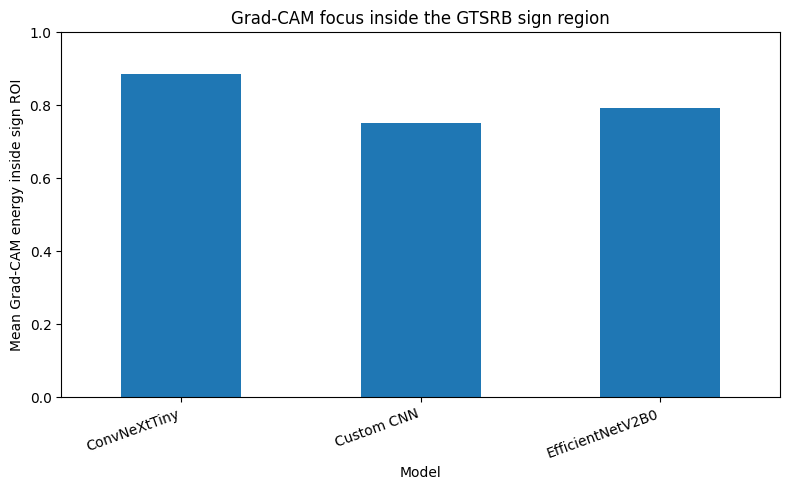

,model,sample_count,correct_count,mean_confidence,mean_roi_attention_ratio,median_roi_attention_ratio
0,ConvNeXtTiny,12,8,0.889075,0.884659,0.894210
1,Custom CNN,12,8,0.844826,0.751478,0.761856
2,EfficientNetV2B0,12,8,0.789034,0.793160,0.770924


,model,selection_category,sample_count,correct_count,mean_confidence,mean_roi_attention_ratio
0,ConvNeXtTiny,difficult_or_misclassified,4,0,0.995979,0.880524
1,ConvNeXtTiny,high_confidence_correct,4,4,1.000000,0.969949
2,ConvNeXtTiny,low_confidence_correct,4,4,0.671245,0.803503
3,Custom CNN,difficult_or_misclassified,4,0,0.984032,0.706944
4,Custom CNN,high_confidence_correct,4,4,1.000000,0.781414
5,Custom CNN,low_confidence_correct,4,4,0.550447,0.766078
6,EfficientNetV2B0,difficult_or_misclassified,4,0,0.982923,0.671784
7,EfficientNetV2B0,high_confidence_correct,4,4,1.000000,0.929050
8,EfficientNetV2B0,low_confidence_correct,4,4,0.384180,0.778647


{
  "selected_samples": 12,
  "models": [
    "Custom CNN",
    "EfficientNetV2B0",
    "ConvNeXtTiny"
  ],
  "gradcam_records": 36,
  "roi_available": true,
  "target_layers": {
    "Custom CNN": "block4_pool",
    "EfficientNetV2B0": "top_activation",
    "ConvNeXtTiny": "layer_normalization"
  },
  "highest_mean_roi_attention_model": "ConvNeXtTiny"
}


In [12]:
gradcam_frame = pd.DataFrame(
    gradcam_records
)

gradcam_frame.to_csv(
    REPORT_DIR / "gradcam_records.csv",
    index=False,
)


summary_arguments = {
    "sample_count": (
        "sample_id",
        "count",
    ),
    "correct_count": (
        "correct",
        "sum",
    ),
    "mean_confidence": (
        "confidence",
        "mean",
    ),
    "mean_roi_attention_ratio": (
        "roi_attention_ratio",
        "mean",
    ),
    "median_roi_attention_ratio": (
        "roi_attention_ratio",
        "median",
    ),
}


gradcam_summary_frame = (
    gradcam_frame
    .groupby(
        "model",
        as_index=False,
    )
    .agg(
        **summary_arguments
    )
)

gradcam_summary_frame.to_csv(
    REPORT_DIR / "gradcam_model_summary.csv",
    index=False,
)


category_summary_frame = (
    gradcam_frame
    .groupby(
        [
            "model",
            "selection_category",
        ],
        as_index=False,
    )
    .agg(
        sample_count=(
            "sample_id",
            "count",
        ),
        correct_count=(
            "correct",
            "sum",
        ),
        mean_confidence=(
            "confidence",
            "mean",
        ),
        mean_roi_attention_ratio=(
            "roi_attention_ratio",
            "mean",
        ),
    )
)

category_summary_frame.to_csv(
    REPORT_DIR / "gradcam_category_summary.csv",
    index=False,
)


summary_json = {
    "selected_samples": int(
        len(selected_frame)
    ),
    "models": list(
        MODEL_PATHS.keys()
    ),
    "gradcam_records": int(
        len(gradcam_frame)
    ),
    "roi_available": bool(
        ROI_AVAILABLE
    ),
    "target_layers": {
        str(row["model"]): str(
            row["target_layer"]
        )
        for _, row in target_layer_frame.iterrows()
    },
}


if ROI_AVAILABLE:
    valid_summary = gradcam_summary_frame.dropna(
        subset=[
            "mean_roi_attention_ratio"
        ]
    )

    if not valid_summary.empty:
        best_index = valid_summary[
            "mean_roi_attention_ratio"
        ].idxmax()

        summary_json[
            "highest_mean_roi_attention_model"
        ] = str(
            valid_summary.loc[
                best_index,
                "model",
            ]
        )


(
    REPORT_DIR / "gradcam_summary.json"
).write_text(
    json.dumps(
        summary_json,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


if ROI_AVAILABLE:
    plt.figure(
        figsize=(8, 5)
    )

    plot_values = (
        gradcam_summary_frame
        .set_index(
            "model"
        )[
            "mean_roi_attention_ratio"
        ]
    )

    plot_values.plot(
        kind="bar"
    )

    plt.xlabel(
        "Model"
    )

    plt.ylabel(
        "Mean Grad-CAM energy inside sign ROI"
    )

    plt.title(
        "Grad-CAM focus inside the GTSRB sign region"
    )

    plt.xticks(
        rotation=20,
        ha="right",
    )

    plt.ylim(
        0.0,
        1.0,
    )

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR
        / "gradcam_roi_attention_comparison.pdf",
        bbox_inches="tight",
    )

    plt.savefig(
        FIGURE_DIR
        / "gradcam_roi_attention_comparison.png",
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()


display(
    gradcam_summary_frame
)

display(
    category_summary_frame
)

print(
    json.dumps(
        summary_json,
        indent=2,
        ensure_ascii=False,
    )
)


## Cell 13 — Verify results and create the ZIP archive

In [13]:
required_outputs = [
    REPORT_DIR
    / "model_information.csv",
    REPORT_DIR
    / "clean_test_predictions_all_models.csv",
    REPORT_DIR
    / "selected_gradcam_samples.csv",
    REPORT_DIR
    / "gradcam_target_layers.csv",
    REPORT_DIR
    / "gradcam_records.csv",
    REPORT_DIR
    / "gradcam_model_summary.csv",
    REPORT_DIR
    / "gradcam_category_summary.csv",
    REPORT_DIR
    / "gradcam_summary.json",
]

if ROI_AVAILABLE:
    required_outputs.append(
        FIGURE_DIR
        / "gradcam_roi_attention_comparison.pdf"
    )

missing_outputs = [
    path
    for path in required_outputs
    if not path.exists()
]

if missing_outputs:
    raise FileNotFoundError(
        f"Missing outputs: {missing_outputs}"
    )


expected_records = (
    len(selected_frame)
    * len(MODEL_PATHS)
)

comparison_png_files = list(
    COMPARISON_DIR.glob(
        "*_comparison.png"
    )
)

comparison_pdf_files = list(
    COMPARISON_DIR.glob(
        "*_comparison.pdf"
    )
)

individual_png_files = list(
    INDIVIDUAL_DIR.rglob(
        "*.png"
    )
)

individual_pdf_files = list(
    INDIVIDUAL_DIR.rglob(
        "*.pdf"
    )
)

heatmap_array_files = list(
    HEATMAP_ARRAY_DIR.rglob(
        "*.npy"
    )
)


print("Grad-CAM records:", len(gradcam_frame))
print("Comparison PNG files:", len(comparison_png_files))
print("Comparison PDF files:", len(comparison_pdf_files))
print("Individual PNG files:", len(individual_png_files))
print("Individual PDF files:", len(individual_pdf_files))
print("Heatmap arrays:", len(heatmap_array_files))


if len(gradcam_frame) != expected_records:
    raise RuntimeError(
        "The number of Grad-CAM records is incorrect."
    )

if len(comparison_png_files) != len(selected_frame):
    raise RuntimeError(
        "The number of comparison PNG files is incorrect."
    )

if len(comparison_pdf_files) != len(selected_frame):
    raise RuntimeError(
        "The number of comparison PDF files is incorrect."
    )

if len(individual_png_files) != expected_records:
    raise RuntimeError(
        "The number of individual PNG files is incorrect."
    )

if len(individual_pdf_files) != expected_records:
    raise RuntimeError(
        "The number of individual PDF files is incorrect."
    )

if len(heatmap_array_files) != expected_records:
    raise RuntimeError(
        "The number of heatmap arrays is incorrect."
    )


archive_path = shutil.make_archive(
    base_name=(
        "/kaggle/working/"
        "gradcam_results"
    ),
    format="zip",
    root_dir=OUTPUT_ROOT,
)

archive_path = Path(
    archive_path
)

print(
    "Archive:",
    archive_path,
)

print(
    "Archive size, MB:",
    round(
        archive_path.stat().st_size
        / 1024
        / 1024,
        2,
    ),
)


if REMOVE_UNPACKED_OUTPUT_AFTER_ZIP:
    # Remove unpacked outputs to make Kaggle version publishing faster.
    shutil.rmtree(
        OUTPUT_ROOT
    )

    print(
        "Unpacked output directory removed:",
        not OUTPUT_ROOT.exists(),
    )


print(
    "GRAD-CAM ANALYSIS COMPLETED SUCCESSFULLY."
)


Grad-CAM records: 36
Comparison PNG files: 12
Comparison PDF files: 12
Individual PNG files: 36
Individual PDF files: 36
Heatmap arrays: 36
Archive: /kaggle/working/gradcam_results.zip
Archive size, MB: 40.78
Unpacked output directory removed: True
GRAD-CAM ANALYSIS COMPLETED SUCCESSFULLY.
